# Banking Customer Portfolio & Exposure Analytics

## 1. Business Context and Objective

In this notebook, I check the raw data and prepare it for the next two analyses. I review missing values, duplicates, data types, categories, ranges, dates, income bands, and possible outliers.

I keep the raw CSV unchanged and do not remove unusual records without a clear reason.

## 2. Imports and Display Settings

I import the packages used for data checks, tables, and charts.

In [1]:
# Import the packages used for paths, data checks, tables, and charts.
from pathlib import Path
import re
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [2]:
# Run this step and check the result.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="deep")

## 3. Load the Raw Dataset

The path works from the project folder or the notebooks folder. I use a copy of the raw data for all changes.

In [ ]:
# Find the project folders and load a copy of the raw CSV.
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "data/raw/Banking.csv").exists() else cwd.parent
raw_path = project_root / "data/raw/Banking.csv"
processed_dir = project_root / "data/processed"
tables_dir = project_root / "reports/tables"
figures_dir = project_root / "reports/figures/data_quality"
if not raw_path.exists():
    raise FileNotFoundError(f"Raw dataset not found: {raw_path}")
for folder in (processed_dir, tables_dir, figures_dir):
    folder.mkdir(parents=True, exist_ok=True)
raw_df = pd.read_csv(raw_path)
df = raw_df.copy()

In [4]:
# Run this step and check the result.
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

Shape: 3,000 rows x 25 columns


,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,"75,384.77","17,677.95",1,484.54,"776,242.92","1,485,828.64","603,617.88","607,332.46","12,249.96","1,134,475.30",1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,"289,834.31","17,398.92",1,"2,256.88","1,270,615.43","641,482.79","229,521.37","344,635.16","61,162.31","2,000,526.10",1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,"169,935.23","42,825.90",2,"4,568.74","1,052,715.84","1,033,401.59","652,674.69","203,054.35","79,071.78","548,137.58",1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,"356,808.11","5,473.15",2,"4,205.00","121,195.06","1,048,157.49","1,048,157.49","234,685.02","57,513.65","1,148,402.29",0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,"130,711.68","48,077.60",1,"3,779.49","1,048,301.95","487,782.53","446,644.25","128,351.45","30,012.14","1,674,412.12",0,3,1,2,5


**Observation:** The raw file contains **3,000 rows and 25 columns**. The raw CSV is never written to or modified.

## 4. Initial Dataset Inspection

I first check the shape, columns, data types, memory use, and basic statistics.

In [5]:
# Display the starting structure and summary statistics.
display(pd.Series(df.columns, name="column"))
df.info(memory_usage="deep")
print(f"Deep memory usage: {df.memory_usage(deep=True).sum():,} bytes")
display(df.describe(include=[np.number]).T)
display(df.describe(include=["object"]).T)

0                    Client ID
1                         Name
2                          Age
3                  Location ID
4                  Joined Bank
5              Banking Contact
6                  Nationality
7                   Occupation
8                Fee Structure
9       Loyalty Classification
10            Estimated Income
11      Superannuation Savings
12      Amount of Credit Cards
13         Credit Card Balance
14                  Bank Loans
15               Bank Deposits
16           Checking Accounts
17             Saving Accounts
18    Foreign Currency Account
19            Business Lending
20            Properties Owned
21              Risk Weighting
22                        BRId
23                    GenderId
24                        IAId
Name: column, dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

,count,mean,std,min,25%,50%,75%,max
Age,"3,000.00",51.04,19.85,17.00,34.00,51.00,69.00,85.00
Location ID,"3,000.00","21,563.32","12,462.27",12.00,"10,803.50","21,129.50","32,054.50","43,369.00"
Estimated Income,"3,000.00","171,305.03","111,935.81","15,919.48","82,906.60","142,313.48","242,290.30","522,330.26"
Superannuation Savings,"3,000.00","25,531.60","16,259.95","1,482.03","12,513.77","22,357.36","35,464.74","75,963.90"
Amount of Credit Cards,"3,000.00",1.46,0.68,1.00,1.00,1.00,2.00,3.00
Credit Card Balance,"3,000.00","3,176.21","2,497.09",1.17,"1,236.63","2,560.81","4,522.63","13,991.99"
Bank Loans,"3,000.00","591,386.16","457,557.04",0.00,"239,628.14","479,793.40","825,813.04","2,667,556.66"
Bank Deposits,"3,000.00","671,560.19","645,716.86",0.00,"204,400.38","463,316.46","942,754.63","3,890,598.08"
Checking Accounts,"3,000.00","321,092.95","282,079.55",0.00,"119,947.53","242,815.65","434,874.94","1,969,923.08"
Saving Accounts,"3,000.00","232,908.35","230,007.78",0.00,"74,794.40","164,086.55","315,575.00","1,724,118.36"


,count,unique,top,freq
Client ID,3000,2940,IND48103,3
Name,3000,2913,Raymond Mills,2
Joined Bank,3000,2579,03-02-2020,4
Banking Contact,3000,49,Ernest Rivera,77
Nationality,3000,5,European,1309
Occupation,3000,195,Structural Analysis Engineer,28
Fee Structure,3000,3,High,1476
Loyalty Classification,3000,4,Jade,1331


**Observation:** Before correction, pandas identifies **9 float, 8 integer, and 8 object columns**. Deep memory usage is approximately **1.82 MB**.

## 5. Data Dictionary

This table records the original name, cleaned name, role, data type, and a short description for each column. Unknown code meanings are left unlabelled.

In [6]:
# Save the original column names for the data dictionary.
original_columns = raw_df.columns.tolist()

In [7]:
# Create a small function that changes one name to snake_case.
def snake(name):
    return re.sub(r"_+", "_", re.sub(r"[^a-z0-9]+", "_", name.strip().lower())).strip(
        "_"
    )

In [8]:
# Save the original column names for the data dictionary.
clean_columns = [snake(c) for c in original_columns]

In [9]:
# Record the analysis role for each column.
roles = {
    "client_id": "Identifier",
    "name": "Identifier",
    "age": "Demographic",
    "location_id": "Categorical segment",
    "joined_bank": "Date",
    "banking_contact": "Categorical segment",
    "nationality": "Demographic",
    "occupation": "Categorical segment",
    "fee_structure": "Ordinal category",
    "loyalty_classification": "Ordinal category",
    "estimated_income": "Financial measure",
    "superannuation_savings": "Financial measure",
    "amount_of_credit_cards": "Product holding",
    "credit_card_balance": "Financial measure",
    "bank_loans": "Financial measure",
    "bank_deposits": "Financial measure",
    "checking_accounts": "Financial measure",
    "saving_accounts": "Financial measure",
    "foreign_currency_account": "Financial measure",
    "business_lending": "Financial measure",
    "properties_owned": "Product holding",
    "risk_weighting": "Ordinal category",
    "brid": "Categorical segment",
    "genderid": "Categorical segment",
    "iaid": "Categorical segment",
}

In [10]:
# Write a short, cautious description for each field.
descriptions = {
    "client_id": "Recorded customer identifier.",
    "name": "Recorded customer name.",
    "age": "Recorded age in years.",
    "location_id": "Internal location code.",
    "joined_bank": "Recorded joining date.",
    "banking_contact": "Recorded banking contact.",
    "nationality": "Recorded nationality.",
    "occupation": "Recorded occupation.",
    "fee_structure": "Recorded fee category.",
    "loyalty_classification": "Recorded loyalty category.",
    "estimated_income": "Estimated income.",
    "superannuation_savings": "Recorded superannuation savings.",
    "amount_of_credit_cards": "Number of credit cards.",
    "credit_card_balance": "Recorded credit-card balance.",
    "bank_loans": "Recorded bank-loan amount.",
    "bank_deposits": "Recorded bank-deposit amount.",
    "checking_accounts": "Recorded checking-account amount.",
    "saving_accounts": "Recorded saving-account amount.",
    "foreign_currency_account": "Recorded foreign-currency account amount.",
    "business_lending": "Recorded business-lending amount.",
    "properties_owned": "Number of properties owned.",
    "risk_weighting": "Recorded ordered risk code.",
    "brid": "Internal BRId code.",
    "genderid": "Internal gender code.",
    "iaid": "Internal IAId code.",
}

In [11]:
# Run this step and check the result.
integer_fields = {"age", "amount_of_credit_cards", "properties_owned", "risk_weighting"}
financial = {c for c, r in roles.items() if r == "Financial measure"}

In [12]:
# Save the original column names for the data dictionary.
data_dictionary = pd.DataFrame(
    {
        "original_column_name": original_columns,
        "clean_column_name": clean_columns,
        "analytical_role": [roles[c] for c in clean_columns],
        "final_data_type": [
            (
                "datetime64[ns]"
                if c == "joined_bank"
                else (
                    "int64"
                    if c in integer_fields
                    else "float64" if c in financial else "category/string"
                )
            )
            for c in clean_columns
        ],
        "description": [descriptions[c] for c in clean_columns],
        "interpretation_note": [
            (
                "Requires business confirmation."
                if c
                in {
                    "location_id",
                    "fee_structure",
                    "loyalty_classification",
                    "risk_weighting",
                    "brid",
                    "genderid",
                    "iaid",
                }
                else (
                    "Units or methodology are not supplied."
                    if c in financial
                    else "Use as recorded; validate against source systems."
                )
            )
            for c in clean_columns
        ],
    }
)

In [13]:
# Build and display the data dictionary.
display(data_dictionary)

,original_column_name,clean_column_name,analytical_role,final_data_type,description,interpretation_note
0,Client ID,client_id,Identifier,category/string,Recorded customer identifier.,Use as recorded; validate against source systems.
1,Name,name,Identifier,category/string,Recorded customer name.,Use as recorded; validate against source systems.
2,Age,age,Demographic,int64,Recorded age in years.,Use as recorded; validate against source systems.
3,Location ID,location_id,Categorical segment,category/string,Internal location code.,Requires business confirmation.
4,Joined Bank,joined_bank,Date,datetime64[ns],Recorded joining date.,Use as recorded; validate against source systems.
5,Banking Contact,banking_contact,Categorical segment,category/string,Recorded banking contact.,Use as recorded; validate against source systems.
6,Nationality,nationality,Demographic,category/string,Recorded nationality.,Use as recorded; validate against source systems.
7,Occupation,occupation,Categorical segment,category/string,Recorded occupation.,Use as recorded; validate against source systems.
8,Fee Structure,fee_structure,Ordinal category,category/string,Recorded fee category.,Requires business confirmation.
9,Loyalty Classification,loyalty_classification,Ordinal category,category/string,Recorded loyalty category.,Requires business confirmation.


**Observation:** Mappings for `location_id`, `brid`, `genderid`, and `iaid`, and currency units for financial fields, are not supplied and are not invented.

## 6. Column-Name Standardization

I change the column names to snake_case so they are easier to use in Python and SQL.

In [14]:
# Save the original column names for the data dictionary.
rename_map = dict(zip(original_columns, clean_columns))
df = df.rename(columns=rename_map)
if df.columns.duplicated().any():
    raise ValueError("Standardization produced duplicate names")
display(pd.DataFrame(rename_map.items(), columns=["original_name", "clean_name"]))

,original_name,clean_name
0,Client ID,client_id
1,Name,name
2,Age,age
3,Location ID,location_id
4,Joined Bank,joined_bank
5,Banking Contact,banking_contact
6,Nationality,nationality
7,Occupation,occupation
8,Fee Structure,fee_structure
9,Loyalty Classification,loyalty_classification


**Observation:** All 25 headers standardize without collisions.

## 7. Missing-Value Analysis

I check both the number and percentage of missing values in every column.

,missing_count,missing_percentage
client_id,0,0.00
credit_card_balance,0,0.00
genderid,0,0.00
brid,0,0.00
risk_weighting,0,0.00
properties_owned,0,0.00
business_lending,0,0.00
foreign_currency_account,0,0.00
saving_accounts,0,0.00
checking_accounts,0,0.00


Total missing cells: 0


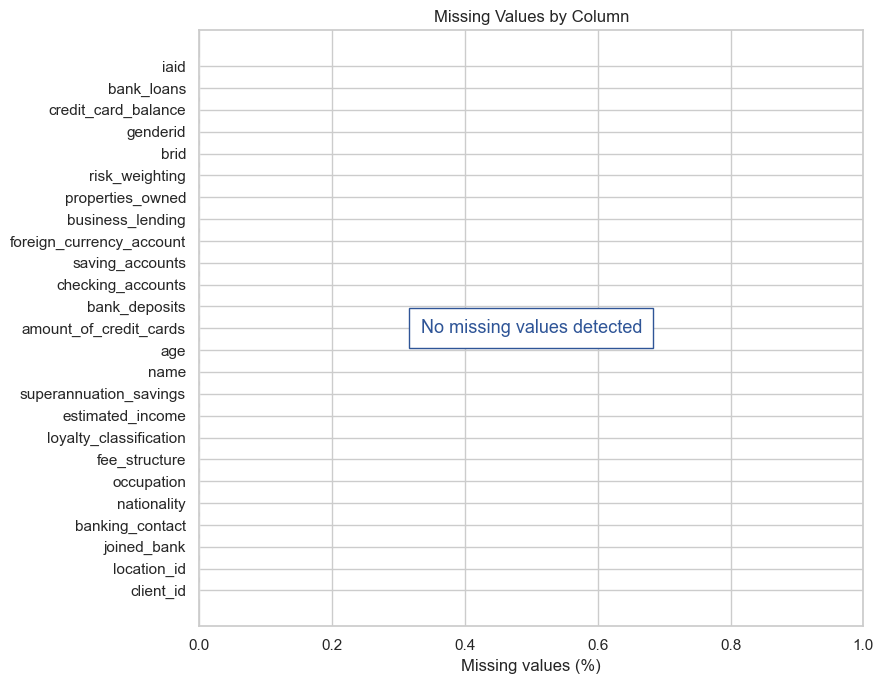

In [15]:
# Calculate missing values and create the missing-value chart.
missing_summary = pd.DataFrame(
    {"missing_count": df.isna().sum(), "missing_percentage": df.isna().mean() * 100}
).sort_values("missing_count", ascending=False)
display(missing_summary)
print(f"Total missing cells: {df.isna().sum().sum():,}")
plot_data = missing_summary.sort_values("missing_percentage")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_data.index, plot_data.missing_percentage, color="#4C78A8")
ax.set(title="Missing Values by Column", xlabel="Missing values (%)", ylabel="")

if plot_data["missing_percentage"].max() == 0:
    ax.set_xlim(0, 1)
    ax.text(
        0.5,
        0.5,
        "No missing values detected",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=13,
        color="#2F5597",
        bbox={"facecolor": "white", "edgecolor": "#2F5597", "pad": 8},
    )
plt.tight_layout()
fig.savefig(figures_dir / "missing_value_percentage.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** No missing values occur in any column; the zero chart records that result explicitly.

## 8. Duplicate and Identifier Validation

I check exact duplicate rows, repeated client IDs, blank text, and extra spaces.

In [16]:
# Count blank text and leading or trailing spaces.
text_cols = df.select_dtypes(include=["object", "string", "category"]).columns
blank_counts = pd.Series(
    {c: df[c].fillna("").astype(str).str.strip().eq("").sum() for c in text_cols},
    name="blank_count",
)
whitespace_counts = pd.Series(
    {
        c: (df[c].dropna().astype(str) != df[c].dropna().astype(str).str.strip()).sum()
        for c in text_cols
    },
    name="whitespace_count",
)

In [17]:
# Summarize duplicate rows and repeated client IDs.
identifier_summary = pd.DataFrame(
    {
        "metric": [
            "row_count",
            "exact_duplicate_rows",
            "unique_client_ids",
            "duplicate_occurrences_after_first",
            "rows_involved_in_repeated_ids",
            "number_of_repeated_client_ids",
            "blank_text_cells",
            "whitespace_affected_cells",
        ],
        "value": [
            len(df),
            df.duplicated().sum(),
            df["client_id"].nunique(),
            df["client_id"].duplicated().sum(),
            df["client_id"].duplicated(keep=False).sum(),
            df.loc[df["client_id"].duplicated(keep=False), "client_id"].nunique(),
            blank_counts.sum(),
            whitespace_counts.sum(),
        ],
    }
)

In [18]:
# Count blank text and leading or trailing spaces.
display(identifier_summary)
display(pd.concat([blank_counts, whitespace_counts], axis=1))
display(df[df.client_id.duplicated(keep=False)].sort_values("client_id").head(20))
print(
    f"client_id is a unique key: {df.client_id.notna().all() and df.client_id.is_unique}"
)

,metric,value
0,row_count,3000
1,exact_duplicate_rows,0
2,unique_client_ids,2940
3,duplicate_occurrences_after_first,60
4,rows_involved_in_repeated_ids,119
5,number_of_repeated_client_ids,59
6,blank_text_cells,0
7,whitespace_affected_cells,0


,blank_count,whitespace_count
client_id,0,0
name,0,0
joined_bank,0,0
banking_contact,0,0
nationality,0,0
occupation,0,0
fee_structure,0,0
loyalty_classification,0,0


,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,estimated_income,superannuation_savings,amount_of_credit_cards,credit_card_balance,bank_loans,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid
1545,IND15088,Margaret Coleman,42,8628,25-12-2010,Keith Griffin,American,Systems Administrator III,Mid,Silver,"286,607.89","21,810.06",2,"6,838.60","1,737,252.30","1,822,218.15","1,111,108.63","192,592.16","38,869.65","2,515,317.76",3,3,3,2,16
740,IND15088,Betty Davis,56,12337,14-03-2013,Jesse Evans,European,Marketing Manager,Mid,Silver,"67,454.44","18,561.11",1,"2,850.42","202,973.22","515,252.11","197,330.60","182,421.17","29,202.53","460,614.28",1,1,3,1,8
378,IND15955,Susan Dunn,20,2035,08-12-2011,Jason Duncan,Asian,Programmer Analyst IV,Mid,Jade,"175,521.36","9,585.66",2,"3,226.24","214,473.24","1,065,362.14","532,681.07","288,300.04","23,692.05","1,671,865.90",2,4,3,2,5
1081,IND15955,Victor Williams,21,26992,29-05-2015,Mark Montgomery,African,Research Assistant IV,High,Jade,"113,678.37","24,738.48",1,"3,529.00","397,665.40","280,450.11","146,541.50","55,180.45","1,292.64","792,193.58",1,1,1,2,9
995,IND17019,Keith Fuller,70,14000,25-10-2014,Jesse Evans,European,Registered Nurse,High,Silver,"210,198.07","53,140.12",1,"6,941.95","359,158.04","2,168,373.56","827,623.49","438,640.45","36,083.69","2,552,969.13",3,5,3,1,10
259,IND17019,Charles Richards,28,26267,05-03-2015,Nicholas Simmons,Asian,Assistant Manager,Mid,Gold,"241,251.12","61,785.90",1,"6,139.25","328,691.19","717,212.31","654,456.23","128,291.35","50,692.09","619,029.46",0,3,3,2,22
1877,IND18812,Samuel Wright,41,18447,12-02-1996,Nicholas Cunningham,African,Administrative Assistant I,High,Silver,"146,174.05","18,695.16",1,"2,513.28","825,633.42","1,026,061.16","233,881.59","286,316.33","3,200.84","1,373,757.65",0,2,1,2,8
2463,IND18812,Emily Ruiz,45,32331,24-03-2004,Anthony Berry,European,Structural Analysis Engineer,Low,Gold,"41,442.10","2,332.13",1,896.52,"220,650.10","58,475.92","53,797.85","34,734.70","7,419.85","75,226.46",0,1,4,1,16
2229,IND19673,Frank Harper,77,31321,07-12-2016,Benjamin Kim,Asian,Database Administrator I,Low,Jade,"191,265.88","11,937.39",1,"4,443.81","637,807.27","2,092,998.26","480,614.41","599,062.61","3,275.19","835,505.64",3,2,1,2,20
2365,IND19673,Deborah James,67,1860,08-01-2017,Victor Martinez,European,Graphic Designer,Mid,Platinum,"123,468.29","19,172.34",1,"1,819.00","412,041.52","74,734.72","91,466.38","11,243.67","12,308.89","202,210.02",1,2,3,1,20


client_id is a unique key: False


**Observation:** There are **no exact duplicate rows**. The dataset contains **2,940 unique client IDs** across 3,000 records: **60 duplicate occurrences after the first**, involving **119 rows across 59 repeated IDs**. Because repeated IDs have conflicting attributes, `client_id` is not a unique row key and no rows are removed without a verified business rule. No blank strings or surrounding whitespace were detected.

## 9. Data-Type Validation and Correction

I convert the joining date and treat internal ID fields as categories instead of continuous numbers.

In [19]:
# Convert the joining date and correct the required data types.
df.joined_bank = pd.to_datetime(df.joined_bank, format="%d-%m-%Y", errors="coerce")

In [20]:
# Run this step and check the result.
category_cols = [
    "client_id",
    "location_id",
    "brid",
    "genderid",
    "iaid",
    "banking_contact",
    "nationality",
    "occupation",
    "fee_structure",
    "loyalty_classification",
]

In [21]:
# Convert the joining date and correct the required data types.
for c in category_cols:
    df[c] = df[c].astype("category")
for c in ["age", "amount_of_credit_cards", "properties_owned", "risk_weighting"]:
    df[c] = pd.to_numeric(df[c], errors="raise").astype("int64")
display(df.dtypes.to_frame("final_dtype"))
print(f"Unparsed dates: {df.joined_bank.isna().sum()}")

,final_dtype
client_id,category
name,object
age,int64
location_id,category
joined_bank,datetime64[ns]
banking_contact,category
nationality,category
occupation,category
fee_structure,category
loyalty_classification,category


Unparsed dates: 0


**Observation:** All joining dates parse successfully. Code fields are categorical; count and ordinal fields remain integers.

## 10. Categorical Consistency Checks

I review category counts, spaces, capitalization, and similar spellings. I do not change names or occupations without evidence.

In [22]:
# Run this step and check the result.
for c in df.select_dtypes(include=["object", "string"]).columns:
    df[c] = df[c].str.strip()
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
rows = []

In [23]:
# Run this step and check the result.
for c in cat_cols:
    values = df[c].dropna().astype(str).str.strip()
    rows.append(
        {
            "column": c,
            "unique_values": values.nunique(),
            "case_only_collisions": values.nunique() - values.str.casefold().nunique(),
            "most_common_value": values.value_counts().index[0],
            "most_common_count": values.value_counts().iloc[0],
        }
    )
    print(f"\n{c}: {values.nunique():,} unique")
    display(values.value_counts().rename("count").to_frame())


client_id: 2,940 unique


,count
client_id,
IND48103,3
IND66163,2
IND35051,2
IND52909,2
IND45303,2
...,...
IND78463,1
IND90097,1
IND91317,1



name: 2,913 unique


,count
name,
Raymond Mills,2
Jennifer Alvarez,2
Joan Allen,2
Jeremy Alexander,2
Karen Black,2
...,...
Justin Ryan,1
Stephen Perry,1
Wayne Fields,1



location_id: 2,890 unique


...

,count
brid,
3,1352
1,660
2,495
4,493



genderid: 2 unique


,count
genderid,
2,1512
1,1488



iaid: 22 unique


,count
iaid,
1,177
3,177
4,177
8,177
2,177
11,176
15,176
14,176
13,176


In [24]:
# Build the categorical consistency summary.
categorical_summary = pd.DataFrame(rows)
display(categorical_summary)
spelling = []

,column,unique_values,case_only_collisions,most_common_value,most_common_count
0,client_id,2940,0,IND48103,3
1,name,2913,0,Raymond Mills,2
2,location_id,2890,0,1031,3
3,banking_contact,49,0,Ernest Rivera,77
4,nationality,5,0,European,1309
5,occupation,195,0,Structural Analysis Engineer,28
6,fee_structure,3,0,High,1476
7,loyalty_classification,4,0,Jade,1331
8,brid,4,0,3,1352
9,genderid,2,0,2,1512


In [25]:
# Check for category labels with very similar spelling.
for c in ["nationality", "fee_structure", "loyalty_classification", "occupation"]:
    values = sorted(df[c].dropna().astype(str).unique())
    for i, left in enumerate(values):
        for right in values[i + 1 :]:
            score = SequenceMatcher(None, left.casefold(), right.casefold()).ratio()
            if score >= 0.90:
                spelling.append(
                    {
                        "column": c,
                        "value_1": left,
                        "value_2": right,
                        "similarity": round(score, 3),
                    }
                )

In [26]:
# Check for category labels with very similar spelling.
display(
    pd.DataFrame(spelling)
    if spelling
    else pd.DataFrame({"result": ["No high-similarity candidates detected."]})
)

,column,value_1,value_2,similarity
0,occupation,Account Representative I,Account Representative II,0.98
1,occupation,Account Representative I,Account Representative III,0.96
2,occupation,Account Representative I,Account Representative IV,0.98
3,occupation,Account Representative II,Account Representative III,0.98
4,occupation,Account Representative II,Account Representative IV,0.96
...,...,...,...,...
156,occupation,Web Developer I,Web Developer III,0.94
157,occupation,Web Developer I,Web Developer IV,0.97
158,occupation,Web Developer II,Web Developer III,0.97
159,occupation,Web Developer II,Web Developer IV,0.94


**Observation:** No case-only collisions, blank values, or surrounding whitespace are detected. Similar labels are review candidates only; no unverified category mappings or spelling corrections are applied.

## 11. Numerical Range and Validity Checks

I check ranges, zero values, negative values, infinite values, and unusual ages or risk codes.

In [27]:
# List the financial columns used in range checks.
financial_cols = [
    "estimated_income",
    "superannuation_savings",
    "credit_card_balance",
    "bank_loans",
    "bank_deposits",
    "checking_accounts",
    "saving_accounts",
    "foreign_currency_account",
    "business_lending",
]

In [28]:
# List the financial columns used in range checks.
num_check = [
    "age",
    *financial_cols,
    "amount_of_credit_cards",
    "properties_owned",
    "risk_weighting",
]

In [29]:
# Create the numerical validity table.
validity = pd.DataFrame(
    {
        "minimum": df[num_check].min(),
        "maximum": df[num_check].max(),
        "zero_count": df[num_check].eq(0).sum(),
        "negative_count": df[num_check].lt(0).sum(),
        "infinite_count": pd.Series(
            {c: np.isinf(df[c].to_numpy(float)).sum() for c in num_check}
        ),
        "unique_values": df[num_check].nunique(),
    }
)

In [30]:
# Create the numerical validity table.
display(validity)
print(
    "Constant columns:", [c for c in df if df[c].nunique(dropna=False) <= 1] or "None"
)
print("Age 17 records:", (df.age == 17).sum())
expected_risk = {1, 2, 3, 4, 5}
unexpected_risk = sorted(set(df.risk_weighting.unique()) - expected_risk)
display(df.risk_weighting.value_counts().sort_index().rename("count").to_frame())
print("Unexpected risk values:", unexpected_risk or "None")

,minimum,maximum,zero_count,negative_count,infinite_count,unique_values
age,17.00,85.00,0,0,0,69
estimated_income,"15,919.48","522,330.26",0,0,0,3000
superannuation_savings,"1,482.03","75,963.90",0,0,0,2997
credit_card_balance,1.17,"13,991.99",0,0,0,2996
bank_loans,0.00,"2,667,556.66",27,0,0,2973
bank_deposits,0.00,"3,890,598.08",34,0,0,2967
checking_accounts,0.00,"1,969,923.08",34,0,0,2967
saving_accounts,0.00,"1,724,118.36",34,0,0,2967
foreign_currency_account,45.00,"124,704.87",0,0,0,3000
business_lending,0.00,"3,825,961.94",14,0,0,2987


Constant columns: None
Age 17 records: 39


,count
risk_weighting,
1,836
2,1222
3,460
4,322
5,160


Unexpected risk values: None


**Observation:** There are no negative or infinite numerical values and no constant columns. Age ranges from 17 to 85; **39 age-17 records** are flagged, not removed. Risk weighting contains only 1?5. Zero financial amounts may represent non-holdings and are retained.

## 12. Date and Joining-Cohort Preparation

I create year, month, month name, and decade fields from the joining date. I do not calculate tenure because there is no confirmed snapshot date.

Date range: 1995-01-03 to 2021-12-31


,joined_bank,join_year,join_month,join_month_name,join_decade
0,2019-05-06,2019,5,May,2010
1,2001-12-10,2001,12,December,2000
2,2010-01-25,2010,1,January,2010
3,2019-03-28,2019,3,March,2010
4,2012-07-20,2012,7,July,2010


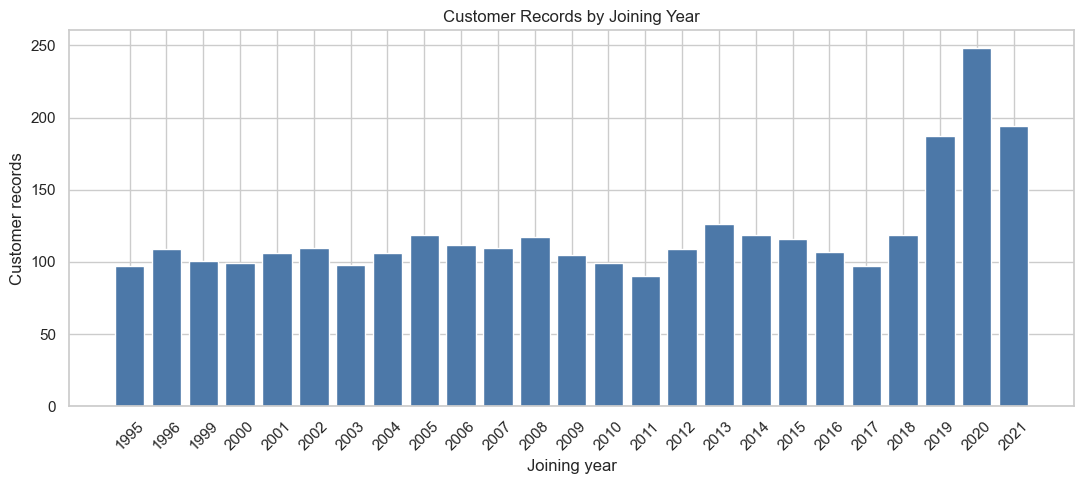

In [31]:
# Convert the joining date and correct the required data types.
df["join_year"] = df.joined_bank.dt.year.astype("Int64")
df["join_month"] = df.joined_bank.dt.month.astype("Int64")
df["join_month_name"] = df.joined_bank.dt.month_name()
df["join_decade"] = (df.join_year // 10 * 10).astype("Int64")
print("Date range:", df.joined_bank.min().date(), "to", df.joined_bank.max().date())
display(
    df[
        ["joined_bank", "join_year", "join_month", "join_month_name", "join_decade"]
    ].head()
)
counts = df.join_year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(counts.index.astype(str), counts.values, color="#4C78A8")
ax.set(
    title="Customer Records by Joining Year",
    xlabel="Joining year",
    ylabel="Customer records",
)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(figures_dir / "joining_year_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** Dates span **3 January 1995 to 31 December 2021**. No records appear for 1997 or 1998; the gap requires source confirmation.

## 13. Income-Band Feature Engineering

I create three project bands: Low below 100,000, Mid from 100,000 to below 300,000, and High from 300,000. These are not official banking thresholds.

In [32]:
# Create and check the Low, Mid, and High income bands.
labels = ["Low", "Mid", "High"]
df["income_band"] = pd.cut(
    df.estimated_income,
    bins=[-np.inf, 100_000, 300_000, np.inf],
    labels=labels,
    right=False,
    ordered=True,
)
display(df.income_band.value_counts(sort=False).rename("customer_count").to_frame())
print("Missing bands:", df.income_band.isna().sum())

,customer_count
income_band,
Low,1027
Mid,1517
High,456


Missing bands: 0


**Observation:** All customers receive a band: **1,027 Low, 1,517 Mid, and 456 High**. These are project-specific analytical labels, not banking or regulatory thresholds.

## 14. Outlier Detection

I use the 1.5 ? IQR rule to flag unusual values for review. I do not remove or cap them because large balances may be genuine.

In [33]:
# List the numerical columns used in the IQR check.
outlier_cols = [
    "age",
    "estimated_income",
    "superannuation_savings",
    "amount_of_credit_cards",
    "credit_card_balance",
    "bank_loans",
    "bank_deposits",
    "checking_accounts",
    "saving_accounts",
    "foreign_currency_account",
    "business_lending",
    "properties_owned",
    "risk_weighting",
]

In [34]:
# Run this step and check the result.
rows = []

In [35]:
# List the numerical columns used in the IQR check.
for c in outlier_cols:
    s = df[c].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    rows.append(
        {
            "column": c,
            "skewness": s.skew(),
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_iqr_boundary": lower,
            "upper_iqr_boundary": upper,
            "potential_outliers": mask.sum(),
            "potential_outlier_percentage": mask.mean() * 100,
        }
    )

In [36]:
# Build the IQR outlier table.
outlier_summary = pd.DataFrame(rows).sort_values(
    "potential_outlier_percentage", ascending=False
)
display(outlier_summary)

,column,skewness,q1,q3,iqr,lower_iqr_boundary,upper_iqr_boundary,potential_outliers,potential_outlier_percentage
8,saving_accounts,2.19,"74,794.40","315,575.00","240,780.60","-286,376.49","676,745.90",155,5.17
6,bank_deposits,1.71,"204,400.38","942,754.63","738,354.26","-903,131.01","2,050,286.01",149,4.97
7,checking_accounts,1.73,"119,947.53","434,874.94","314,927.41","-352,443.58","907,266.05",138,4.60
10,business_lending,1.15,"374,825.14","1,185,110.07","810,284.94","-840,602.27","2,400,537.48",93,3.10
4,credit_card_balance,1.13,"1,236.63","4,522.63","3,286.00","-3,692.37","9,451.64",85,2.83
5,bank_loans,1.18,"239,628.14","825,813.04","586,184.90","-639,649.21","1,705,090.39",85,2.83
9,foreign_currency_account,1.12,"11,916.54","41,966.39","30,049.85","-33,158.23","87,041.17",79,2.63
1,estimated_income,0.88,"82,906.60","242,290.30","159,383.71","-156,168.97","481,365.87",26,0.87
2,superannuation_savings,0.71,"12,513.77","35,464.74","22,950.96","-21,912.67","69,891.19",19,0.63
0,age,0.01,34.00,69.00,35.00,-18.50,121.50,0,0.00


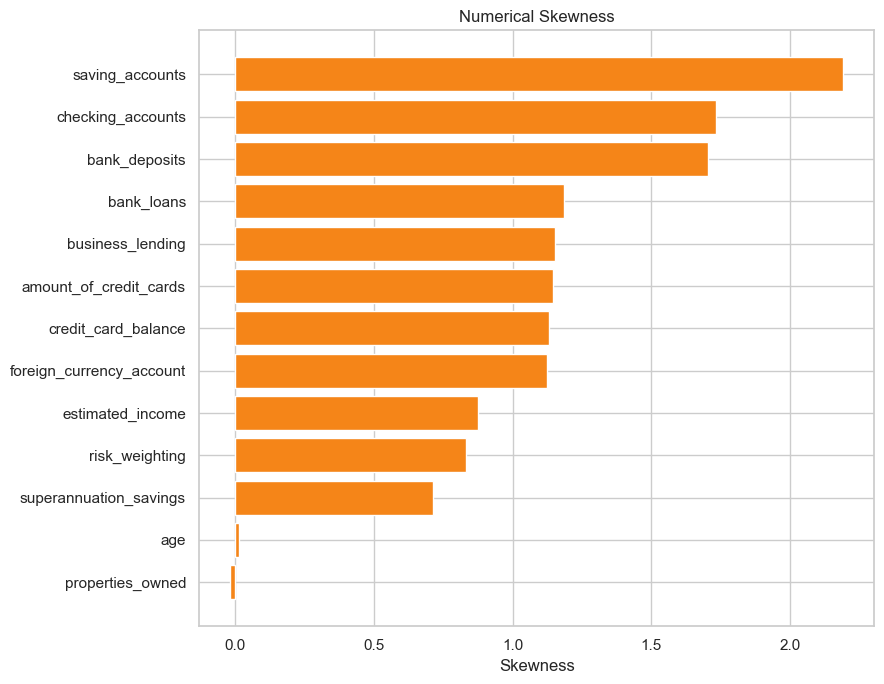

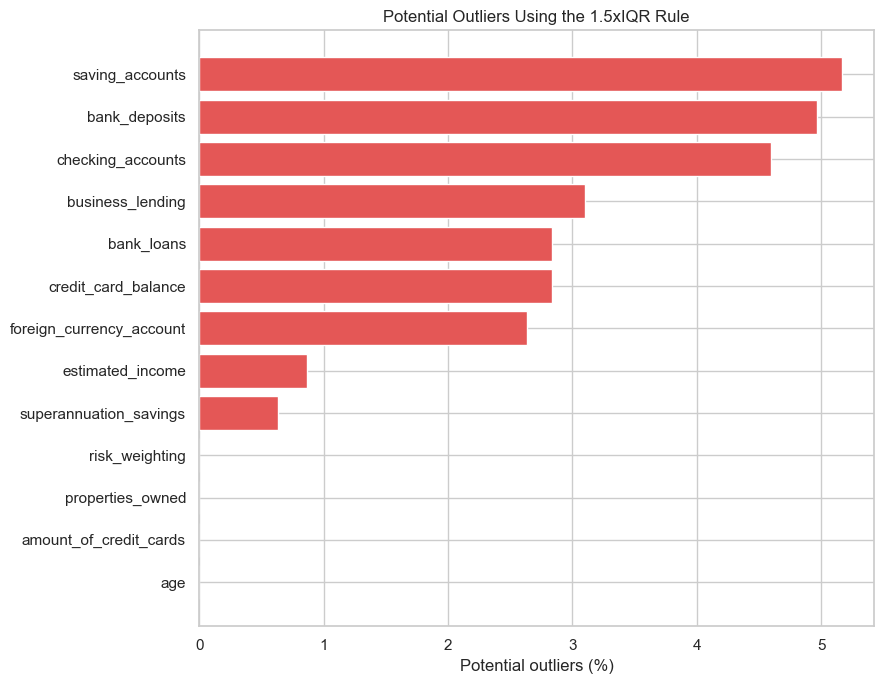

In [37]:
# Build the IQR outlier table.
for field, color, title, file, xlabel in [
    ("skewness", "#F58518", "Numerical Skewness", "numerical_skewness.png", "Skewness"),
    (
        "potential_outlier_percentage",
        "#E45756",
        "Potential Outliers Using the 1.5xIQR Rule",
        "potential_outlier_percentage.png",
        "Potential outliers (%)",
    ),
]:
    plot = outlier_summary.sort_values(field)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(plot.column, plot[field], color=color)
    ax.set(title=title, xlabel=xlabel, ylabel="")
    plt.tight_layout()
    fig.savefig(figures_dir / file, dpi=300, bbox_inches="tight")
    plt.show()

**Observation:** Saving accounts has the highest potential-outlier rate (**5.17%**), followed by bank deposits (**4.97%**) and checking accounts (**4.60%**). These are flags, not errors.

## 15. Data-Quality Summary

This table collects the main checks in one place.

In [38]:
# Build the final data-quality summary table.
data_quality_summary = pd.DataFrame(
    [
        {"check": "Row count", "result": len(df), "status": "Pass"},
        {"check": "Missing cells", "result": int(df.isna().sum().sum()), "status": "Pass"},
        {"check": "Exact duplicate rows", "result": int(df.duplicated().sum()), "status": "Pass"},
        {"check": "Unique client IDs", "result": int(df["client_id"].nunique()), "status": "Review"},
        {"check": "Duplicate occurrences after first", "result": int(df["client_id"].duplicated().sum()), "status": "Review"},
        {"check": "Rows involved in repeated IDs", "result": int(df["client_id"].duplicated(keep=False).sum()), "status": "Review"},
        {"check": "Number of repeated client IDs", "result": int(df.loc[df["client_id"].duplicated(keep=False), "client_id"].nunique()), "status": "Review"},
        {"check": "Blank text cells", "result": int(blank_counts.sum()), "status": "Pass"},
        {"check": "Invalid dates", "result": int(df["joined_bank"].isna().sum()), "status": "Pass"},
        {"check": "Age-17 records", "result": int((df["age"] == 17).sum()), "status": "Review"},
        {"check": "Negative financial values", "result": int(df[financial_cols].lt(0).sum().sum()), "status": "Pass"},
        {"check": "Unexpected risk values", "result": len(unexpected_risk), "status": "Pass"},
        {"check": "Missing income bands", "result": int(df["income_band"].isna().sum()), "status": "Pass"},
    ]
)

In [39]:
# Build the final data-quality summary table.
display(data_quality_summary)

,check,result,status
0,Row count,3000,Pass
1,Missing cells,0,Pass
2,Exact duplicate rows,0,Pass
3,Unique client IDs,2940,Review
4,Duplicate occurrences after first,60,Review
5,Rows involved in repeated IDs,119,Review
6,Number of repeated client IDs,59,Review
7,Blank text cells,0,Pass
8,Invalid dates,0,Pass
9,Age-17 records,39,Review


**Observation:** The dataset has no missing cells or exact duplicate rows. The main review items are **60 duplicate ID occurrences after the first**, **119 rows sharing 59 repeated IDs**, and **39 records with age 17**. These issues are retained because the dataset provides no verified correction or exclusion rule.

## 16. Export the Prepared Dataset

I run the final checks, save the tables and cleaned CSV, then read the exported file again to confirm it.

In [40]:
# Convert the joining date and correct the required data types.
checks = {
    "row_count_preserved": len(df) == len(raw_df),
    "client_id_complete": df.client_id.notna().all(),
    "client_id_unique": df.client_id.is_unique,
    "no_missing_values": not df.isna().any().any(),
    "no_exact_duplicates": not df.duplicated().any(),
    "income_band_complete": df.income_band.notna().all(),
    "joined_bank_is_datetime": pd.api.types.is_datetime64_any_dtype(df.joined_bank),
}
display(pd.Series(checks, name="passed").to_frame())

,passed
row_count_preserved,True
client_id_complete,True
client_id_unique,False
no_missing_values,True
no_exact_duplicates,True
income_band_complete,True
joined_bank_is_datetime,True


In [41]:
# Build and display the data dictionary.
required = [
    "row_count_preserved",
    "client_id_complete",
    "no_missing_values",
    "no_exact_duplicates",
    "income_band_complete",
    "joined_bank_is_datetime",
]
if not all(checks[k] for k in required):
    raise ValueError("Required export validation failed")
print("Client ID uniqueness is a documented review issue; all rows are preserved.")
data_dictionary.to_csv(tables_dir / "data_dictionary.csv", index=False)

Client ID uniqueness is a documented review issue; all rows are preserved.


In [42]:
# Build the categorical consistency summary.
data_quality_summary.to_csv(tables_dir / "data_quality_summary.csv", index=False)
outlier_summary.to_csv(tables_dir / "outlier_summary.csv", index=False)
categorical_summary.to_csv(tables_dir / "categorical_summary.csv", index=False)
processed_path = processed_dir / "banking_customers_clean.csv"
df.to_csv(processed_path, index=False, date_format="%Y-%m-%d")
exported = pd.read_csv(processed_path)
print("Exported:", processed_path)
print("Shape:", exported.shape)
print("Shape matches:", exported.shape == df.shape)
print("Columns match:", exported.columns.tolist() == df.columns.tolist())
display(exported.head())

Exported: C:\tmp\Data_Analytics_publish_fresh\Projects\banking-customer-analytics\data\processed\banking_customers_clean.csv
Shape: (3000, 30)
Shape matches: True
Columns match: True


,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,estimated_income,superannuation_savings,amount_of_credit_cards,credit_card_balance,bank_loans,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid,join_year,join_month,join_month_name,join_decade,income_band
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,"75,384.77","17,677.95",1,484.54,"776,242.92","1,485,828.64","603,617.88","607,332.46","12,249.96","1,134,475.30",1,2,1,1,1,2019,5,May,2010,Low
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,"289,834.31","17,398.92",1,"2,256.88","1,270,615.43","641,482.79","229,521.37","344,635.16","61,162.31","2,000,526.10",1,3,2,1,2,2001,12,December,2000,Mid
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,"169,935.23","42,825.90",2,"4,568.74","1,052,715.84","1,033,401.59","652,674.69","203,054.35","79,071.78","548,137.58",1,3,3,2,3,2010,1,January,2010,Mid
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,"356,808.11","5,473.15",2,"4,205.00","121,195.06","1,048,157.49","1,048,157.49","234,685.02","57,513.65","1,148,402.29",0,4,4,1,4,2019,3,March,2010,High
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,"130,711.68","48,077.60",1,"3,779.49","1,048,301.95","487,782.53","446,644.25","128,351.45","30,012.14","1,674,412.12",0,3,1,2,5,2012,7,July,2010,Mid


**Observation:** After execution, the prepared export should contain **3,000 rows and 30 columns**: 25 standardized source fields, four joining-cohort fields, and `income_band`. Four tables and four figures will be generated.

## 17. Conclusions and Limitations

No rows were removed. The main limitations are:

- The file has 60 duplicate ID occurrences after the first, involving 119 rows across 59 repeated IDs.
- There are 39 records with age 17; they need review but may still be valid.
- Internal ID meanings, financial units, and valuation dates are not provided.
- Deposit, checking, and saving fields may overlap, so I do not add them together.
- The direction of `risk_weighting` is not confirmed.
- There is no snapshot date, so I do not calculate true tenure.
- There is no default, repayment, or loss target, so this project does not predict default.
- Possible outliers are kept because high balances may be real.